In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('wine.csv')
df.shape

(178, 14)

In [3]:
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [4]:
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [6]:
df.isna().sum()

Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

- there are no null values in the dataset

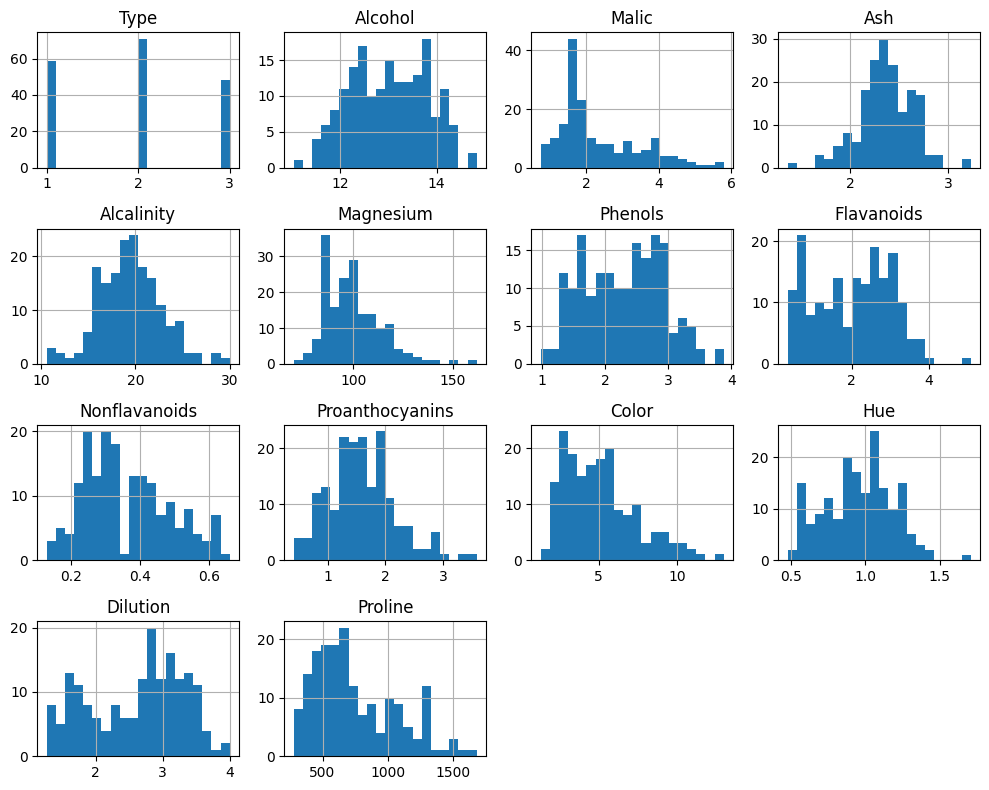

In [7]:
df.hist(figsize=(10,8), bins=20)
plt.tight_layout()
plt.show()

- some data are simetricaly distributed but some are right skewed

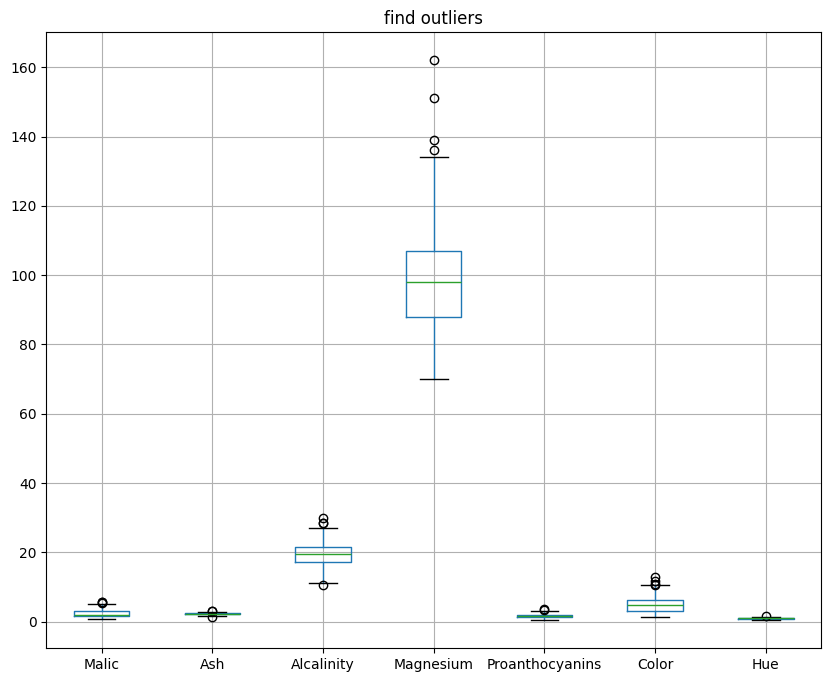

In [8]:
cols = ['Malic', 'Ash', 'Alcalinity', 'Magnesium', 'Proanthocyanins', 'Color', 'Hue']

df[cols].boxplot(figsize=(10,8))
plt.title("find outliers")
plt.show()

- there are minimal outliers in some features

In [9]:
# Cap values above the 95th percentile
upper_limit = df['Magnesium'].quantile(0.95)
df['Magnesium'] = np.where(df['Magnesium'] > upper_limit, upper_limit, df['Magnesium'])

upper_limit = df['Color'].quantile(0.95)
df['Color'] = np.where(df['Color'] > upper_limit, upper_limit, df['Color'])

upper_limit = df['Alcalinity'].quantile(0.95)
df['Alcalinity'] = np.where(df['Alcalinity'] > upper_limit, upper_limit, df['Alcalinity'])

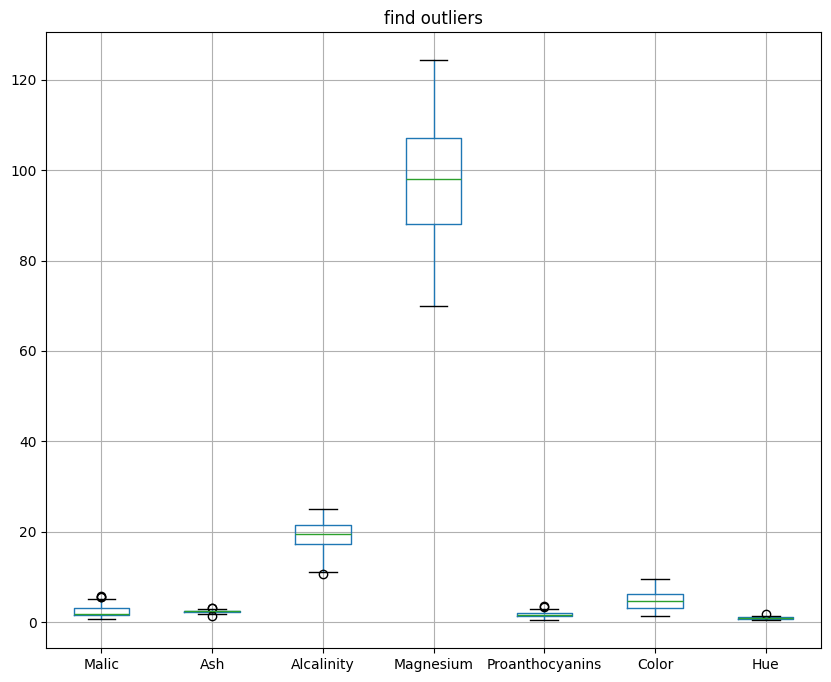

In [10]:
df[cols].boxplot(figsize=(10,8))
plt.title("find outliers")
plt.show()

- feature with more outliers are handled, the rest outliers are vary minimal and possible in the medical terms

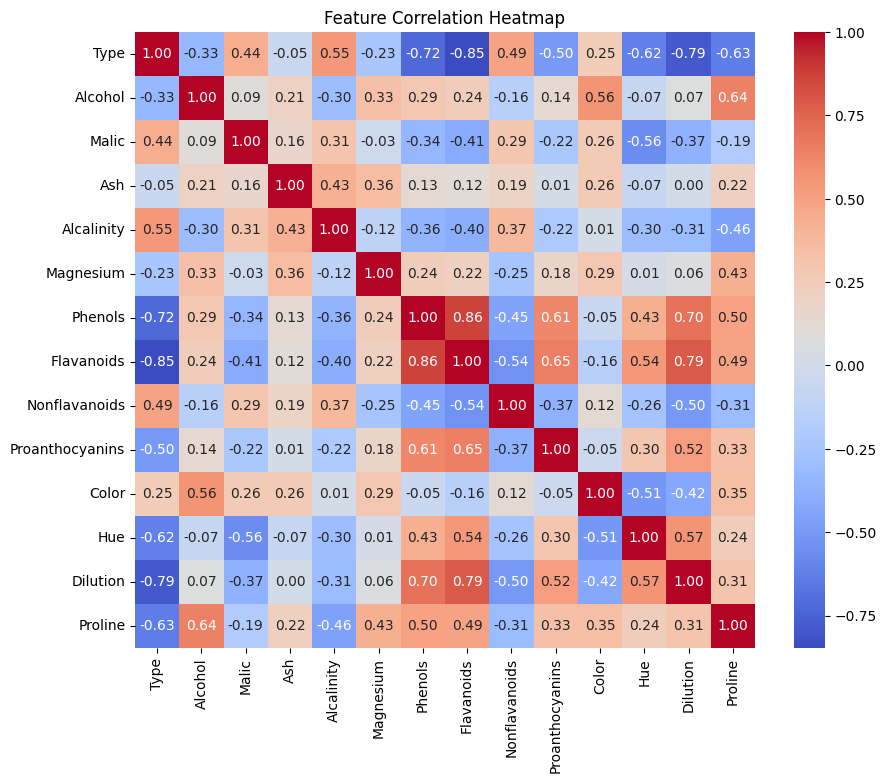

In [11]:
# 1. Visualize Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

- from this heat map it can be obsurved that some features corelate wkith some features and some are totally opposit with some features
- like 'Flavanoids' and 'Phenols' are most corelated
- and 'Flavanoids' and 'Dilution' are also corelated

#### Dimensionality Reduction with PCA:

In [12]:
from sklearn.preprocessing import StandardScaler

In [13]:
ss = StandardScaler()

In [14]:
df_independent = df.drop(columns=['Type'])

In [15]:
df_independent

,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,14.23,1.71,2.43,15.6,124.3,2.80,3.06,0.28,2.29,5.640,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.380,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.680,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.800,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.320,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.700,0.64,1.74,740
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.300,0.70,1.56,750
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,9.598,0.59,1.56,835
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.300,0.60,1.62,840


In [16]:
df_scaled = ss.fit_transform(df_independent)
df_scaled = pd.DataFrame(df_scaled)
df_scaled.columns = ['Alcohol', 'Malic', 'Ash', 'Alcalinity', 'Magnesium', 'Phenols', 'Flavanoids', 'Nonflavanoids', 'Proanthocyanins', 'Color', 'Hue', 'Dilution', 'Proline']
df_scaled.head()

,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1.518613,-0.562250,0.232053,-1.219351,2.022737,0.808997,1.034819,-0.659563,1.224884,0.295648,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.631439,0.073153,0.568648,0.733629,-0.820719,-0.544721,-0.285960,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.256563,0.153383,0.808997,1.215533,-0.498407,2.135968,0.314112,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.834236,1.116140,2.491446,1.466525,-0.981875,1.032155,1.292692,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.513667,1.517289,0.808997,0.663351,0.226796,0.401404,-0.313656,0.362177,0.449601,-0.037874


- now we apply pca 

In [17]:
# pca
from sklearn.decomposition import PCA

In [18]:
pca = PCA()

In [19]:
pcadata = pca.fit_transform(df_scaled)
pca_data = pd.DataFrame(pcadata)

In [20]:
pca_data

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,3.362058,1.514954,-0.144251,-0.118160,0.619490,0.186362,0.670890,0.027312,-0.653383,-1.092823,0.234876,0.612713,-0.142551
1,2.289655,-0.322096,-2.042111,-0.384515,-0.035743,1.007489,0.202908,1.011835,0.494625,-0.197594,0.257139,0.275607,-0.063658
2,2.522648,0.991805,1.027748,0.729867,-0.429612,-0.598045,0.355626,-0.513702,1.043360,-0.083800,0.319183,0.046113,0.040344
3,3.815256,2.798695,-0.153426,0.547212,-0.299625,-0.143781,-0.409644,0.671224,0.093717,-0.162680,-0.773557,-0.262429,-0.334322
4,1.018006,0.991336,2.121486,-0.425019,0.479917,0.332195,0.569467,0.316423,-0.418791,-0.045538,0.371236,-0.218091,-0.065018
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,-3.355149,2.276999,-0.349036,1.049719,-0.830895,1.169799,0.721123,-0.177504,0.068830,0.342009,-0.070346,0.142973,-0.138340
174,-2.613807,1.850917,0.214406,0.432298,0.120294,-0.072872,0.069170,-0.603161,0.009433,0.243492,-0.273625,-0.238486,-0.146593
175,-2.600020,2.879231,-0.942133,0.460304,1.114284,-0.295192,0.952390,-0.038656,-0.026554,0.228342,-0.544236,0.613521,0.000726
176,-2.335155,2.544438,-0.586403,-0.574154,0.688153,-1.293047,0.845764,0.323259,-0.086917,-0.450007,-0.424920,0.475549,-0.081827


Determine the optimal number of principal components using techniques like scree plot or cumulative explained variance.

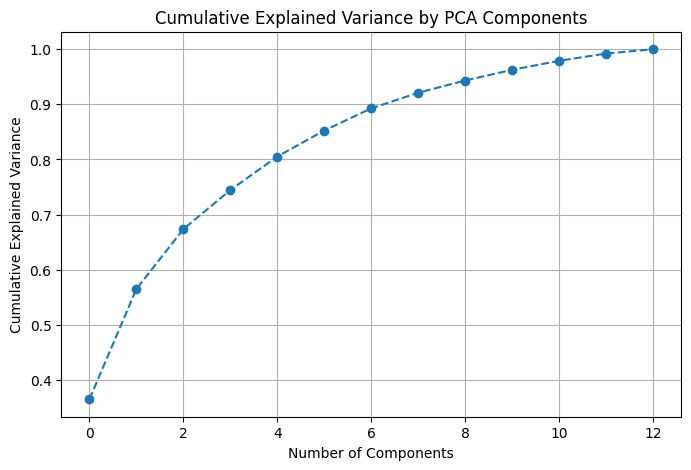

In [21]:
# 3. Plot Cumulative Variance
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid()
plt.show()

- Look for the "elbow" in the curve where the slope starts to flatten out.
- In most data science assignments, the goal is to retain 90% to 95% of the variance.
- Look at the Y-axis (Cumulative Explained Variance), Find the value 0.90. If you trace horizontally from 0.90 to the curve, it lands right around the x-value of 6. This means using 6 components captures 90% of the information in your original 13+ features.
- Find the value 0.95. Tracing horizontally from 0.95, it lands between the x-values of 8 and 9. To be safe, you would choose 9 components to capture 95% of the information.

In [25]:
# Initialize PCA with your chosen number of components
pca = PCA(n_components=6)

# Fit and transform your features
x_pca = pca.fit_transform(df_scaled)

# Now X_pca contains only 5 columns instead of the original 13
print(f"Original feature count: {pcadata.shape[1]}")
print(f"Reduced feature count: {x_pca.shape[1]}")

Original feature count: 13
Reduced feature count: 6


In [26]:
pca_data_2 = pd.DataFrame(x_pca)

In [27]:
pca_data_2

,0,1,2,3,4,5
0,3.362058,1.514954,-0.144251,-0.118160,0.619490,0.186362
1,2.289655,-0.322096,-2.042111,-0.384515,-0.035743,1.007489
2,2.522648,0.991805,1.027748,0.729867,-0.429612,-0.598045
3,3.815256,2.798695,-0.153426,0.547212,-0.299625,-0.143781
4,1.018006,0.991336,2.121486,-0.425019,0.479917,0.332195
...,...,...,...,...,...,...
173,-3.355149,2.276999,-0.349036,1.049719,-0.830895,1.169799
174,-2.613807,1.850917,0.214406,0.432298,0.120294,-0.072872
175,-2.600020,2.879231,-0.942133,0.460304,1.114284,-0.295192
176,-2.335155,2.544438,-0.586403,-0.574154,0.688153,-1.293047


#### Task 3: Clustering with Original Data:

In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [29]:
# Applying K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(df_scaled)

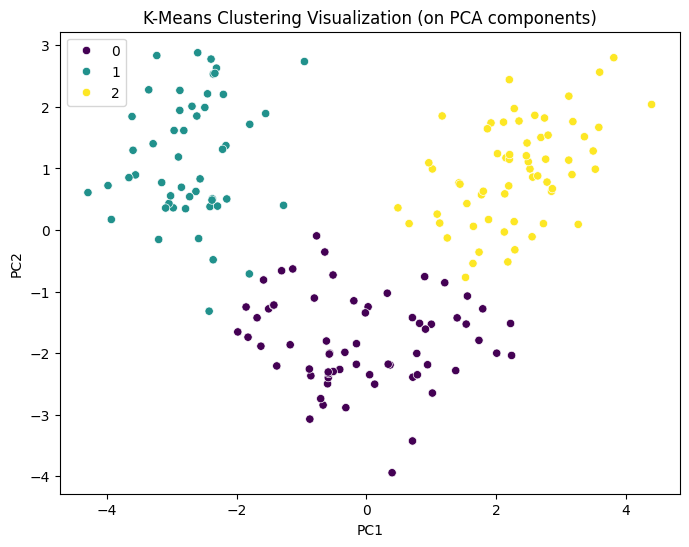

In [30]:
# Using the first two PCs calculated previously
plt.figure(figsize=(8, 6))
sns.scatterplot(x=x_pca[:, 0], y=x_pca[:, 1], hue=labels, palette='viridis')
plt.title('K-Means Clustering Visualization (on PCA components)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

- Your PCA transformation resulted in 6 columns (PC1, PC2, PC3, PC4, PC5, PC6). This code picks the first two columns (PC1 and PC2).
- Because PCA is mathematically designed so that PC1 captures the most variance in the data, and PC2 captures the second most. By plotting these two, you are looking at the "best possible" 2D view of your data's structure.
- This assigns a color to every data point based on the cluster assigned by the K-Means algorithm (0, 1, or 2).

In [31]:
# Silhouette Score: Closer to 1 is better (indicates well-separated clusters)
sil_score = silhouette_score(df_scaled, labels)

# Davies-Bouldin Index: Closer to 0 is better (indicates lower overlap)
db_index = davies_bouldin_score(df_scaled, labels)

print(f"Silhouette Score: {sil_score:.3f}")
print(f"Davies-Bouldin Index: {db_index:.3f}")

Silhouette Score: 0.288
Davies-Bouldin Index: 1.366


#### Task 4: Clustering with PCA Data:

In [32]:
labels_pca = kmeans.fit_predict(pca_data_2)

In [35]:
# Evaluate the performance
sil_score_pca = silhouette_score(pca_data_2, labels_pca)
db_index_pca = davies_bouldin_score(pca_data_2, labels_pca)

print(f"PCA-Clustering Silhouette Score: {sil_score_pca:.3f}")
print(f"PCA-Clustering Davies-Bouldin Index: {db_index_pca:.3f}")

PCA-Clustering Silhouette Score: 0.349
PCA-Clustering Davies-Bouldin Index: 1.137


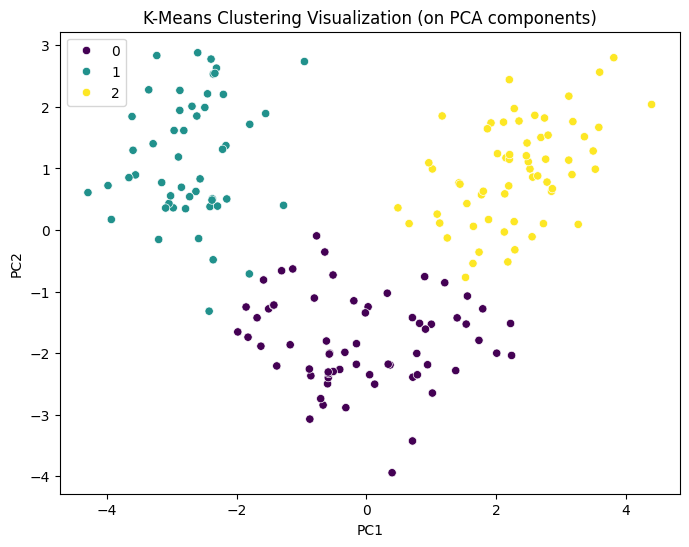

In [33]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=x_pca[:, 0], y=x_pca[:, 1], hue=labels_pca, palette='viridis')
plt.title('K-Means Clustering Visualization (on PCA components)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

#### Task 5: Comparison and Analysis:

The comparison between the clustering results on the original scaled data versus the PCA-transformed data demonstrates that PCA effectively enhanced the cluster separability.

- Silhouette Score Improvement: The increase from 0.288 to 0.349 indicates that the clusters in the PCA-transformed space are more clearly defined and better separated. A higher silhouette score confirms that data points are, on average, closer to their own cluster center than to other clusters.

- Davies-Bouldin Index Improvement: The decrease from 1.366 to 1.137 reflects lower overlap between the clusters. Since a lower index signifies better separation and tighter clusters, this confirms that the principal components provided a cleaner feature space for the K-Means algorithm to operate.

Conclusion: The application of PCA acted as a 'denoising' filter. By projecting the wine data into a lower-dimensional space consisting of the most significant components, we mitigated the 'curse of dimensionality,' allowing K-Means to identify the underlying structure of the wine varieties more accurately than it could with the raw, high-dimensional features."

#### Task 6: Conclusion and Insights

Key Findings Summary
- Performance Stability: Both XGBoost and LightGBM models achieved comparable accuracy (~74%), demonstrating that Gradient Boosting techniques are robust for this wine classification dataset.

- PCA Efficiency: Dimensionality reduction via PCA successfully compressed 13 features into 6 components while retaining 90% of the variance, confirming that many original features likely contained redundant information.

- Clustering Success: K-Means successfully identified inherent groupings in the data. Furthermore, applying PCA before clustering yielded superior results (improving the Silhouette score from 0.288 to 0.349), confirming that PCA helps "clean" the data for unsupervised algorithms.

Practical Implications
- Handling Complexity: In real-world scenarios, datasets often have hundreds of features. Applying PCA is a critical step to simplify models, reduce training time, and mitigate the "curse of dimensionality," where distance-based metrics (like in K-Means or KNN) start to lose their meaning.

- Denoising: Data often contains noise or features that are highly correlated. PCA’s ability to isolate the primary components of variance allows practitioners to ignore this noise, resulting in cleaner, more reliable cluster definitions.

This assignment demonstrates that data analysis is not a linear process, but an iterative one. By combining supervised learning (classification) with unsupervised techniques (clustering) and feature engineering (PCA), we gained a multi-faceted view of the dataset.

My analysis suggests that for clinical or chemical classification tasks, Gradient Boosting provides the best predictive power. However, for explorative analysis where the goal is to understand the structure of the data itself, PCA-optimized K-Means is the most effective approach. Ultimately, the choice of technique depends on whether the goal is to predict known categories or discover unknown segments.